In [45]:
import os, sys
import numpy as np
import pandas as pd
import tifffile as tf

import matplotlib.pyplot as plt
import matplotlib.cm as cm

import h5py

sys.path.append(os.path.normpath(r'C:\Users\Manhyuk\github\MultiSpotsAnalysis'))
import multispots.preprocess as mpp
import multispots.segment as mseg
import multispots.alignment as mal
import multispots.localization as mloc


colors = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4',
          '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff',
          '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1',
          '#000075', '#808080', '#000000']


storage_path = 'G:/Seeun/2025-09-19-MAZ'
image_save_path = r'S:\Seeun\ORCA\images\MAZ_20250919'
os.makedirs(image_save_path, exist_ok=True)

In [2]:
datpath = os.path.normpath(r'S:\Seeun\ORCA\2025-09-19-SG_MAZ_AD293_IF488+10ug\2025-09-19-SG+MAZ+AD293+IF488+10ug')
depth = 109
num_channels = 3
fiducial_channel = 555
channel_list = [555,647,488]
job_name = 'Job 2 02'
template = 'M_and_F_Pos++FOV++__++JobCode++_001.tif'

In [3]:
trial_path_dict = {
r'S:/Seeun/ORCA/2025-09-19-SG_MAZ_AD293_IF488+10ug/2025-09-19-SG+MAZ+AD293+IF488+10ug/2025-09-19_Bleach_R1~R18_T18': [200, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 1018],
r'S:/Seeun/ORCA/2025-09-19-SG_MAZ_AD293_IF488+10ug/2025-09-19-SG+MAZ+AD293+IF488+10ug/2025-09-20_Bleach_R19_R22_R104~R105': [0, 19, 22, 104, 105],
r'S:/Seeun/ORCA/2025-09-19-SG_MAZ_AD293_IF488+10ug/2025-09-19-SG+MAZ+AD293+IF488+10ug/2025-09-21_R106': [106],
r'S:/Seeun/ORCA/2025-09-19-SG_MAZ_AD293_IF488+10ug/2025-09-19-SG+MAZ+AD293+IF488+10ug/2025-09-21_R107~R109_final': [107, 108, 109],
r'S:/Seeun/ORCA/2025-09-19-SG_MAZ_AD293_IF488+10ug/2025-09-19-SG+MAZ+AD293+IF488+10ug/2025-09-21_R110~R114_R68~R69': [110, 111, 112, 113, 114, 68, 69],
r'S:/Seeun/ORCA/2025-09-19-SG_MAZ_AD293_IF488+10ug/2025-09-19-SG+MAZ+AD293+IF488+10ug/2025-09-22_R70~R72': [70, 71 ,72],
r'S:/Seeun/ORCA/2025-09-19-SG_MAZ_AD293_IF488+10ug/2025-09-19-SG+MAZ+AD293+IF488+10ug/2025-09-22-R75~R78': [75, 76, 77, 78],
r'S:/Seeun/ORCA/2025-09-19-SG_MAZ_AD293_IF488+10ug/2025-09-19-SG+MAZ+AD293+IF488+10ug/2025-09-22-R20_R23_R81_R87~R88_R104~R105_T105':[20, 23, 81, 87, 88, -104, -105, 1105],
#r'S:\Seeun\ORCA\2025-09-19-SG_MAZ_AD293_IF488+10ug\2025-09-19-SG+MAZ+AD293+IF488+10ug\2025-09-23-BF+DAPI+Cy3': [300]
}

fov_list = np.unique([int(l.split('Pos')[1].split('_')[0]) for l in os.listdir(trial_path_dict.keys().__iter__().__next__())
                        if l.endswith(template.split('++FOV++')[1].replace('++JobCode++', job_name))]).tolist()

In [4]:
for fov in fov_list:
    """
    mpp.convert_tiff_to_h5_worker(trial_path=r'S:/Seeun/ORCA/2025-09-19-SG_MAZ_AD293_IF488+10ug/2025-09-19-SG+MAZ+AD293+IF488+10ug/2025-09-19_Bleach_R1~R18_T18',
                                readouts=['H200'],
                                fov=fov,
                                channel_list=[555,647,488],
                                depth=109,
                                storage_path=storage_path,
                                fiducial_channel=fiducial_channel,
                                template=template,
                                job_name=job_name)

    mpp.convert_tiff_to_h5_worker(trial_path=r'S:/Seeun/ORCA/2025-09-19-SG_MAZ_AD293_IF488+10ug/2025-09-19-SG+MAZ+AD293+IF488+10ug/2025-09-23-BF+DAPI+Cy3',
                                readouts=['H300'],
                                fov=fov,
                                channel_list=['BF',405,555],
                                depth=109,
                                fiducial_channel=fiducial_channel,
                                storage_path=storage_path,
                                template=template,
                                job_name=job_name)"""

"""
mpp.convert_tiff_to_h5_main(trial_path_dict, list(range(1,41)), channel_list=channel_list, fiducial_channel=fiducial_channel,
                            depth=depth, storage_path=storage_path, job_name=job_name, template=template,
                            num_workers=24)
"""

'\nmpp.convert_tiff_to_h5_main(trial_path_dict, list(range(1,41)), channel_list=channel_list, fiducial_channel=fiducial_channel,\n                            depth=depth, storage_path=storage_path, job_name=job_name, template=template,\n                            num_workers=24)\n'

In [5]:
hybe_list = mpp.reorder_hybe_list_frompath(os.path.join(storage_path, 'FOV01'))

In [6]:
vlink_path = mpp.vlinks_h5(storage_path, fov_list, overwrite=False)
#vlink_path = os.path.join(storage_path,'vlinks.h5')

In [7]:
#with h5py.File(vlink_path, 'r') as f:
#    reference_mip = f[f'/FOV01/mip/ch555'][0]
#mpp.align_mips_worker(storage_path, 1, 'H105','H1', reference_mip, 555,)

In [8]:
#mpp.align_mips_main(storage_path, fov_list, hybe_list, reference_hybe='H1', reference_channel=555, num_workers=24,)

In [9]:
"""for fov in fov_list:
    for hybe in hybe_list:
        with h5py.File(os.path.join(storage_path, f'FOV{fov:02d}', f'{hybe}_stack.h5'), 'r+') as f:
            if hybe == 'H300':
                f.attrs['channel_list'] = np.array(['BF', '405', '555'], dtype='S')
            else:
                f.attrs['channel_list'] = np.array(channel_list, dtype='S')
            print(f.attrs['channel_list'], fov, hybe)"""

"for fov in fov_list:\n    for hybe in hybe_list:\n        with h5py.File(os.path.join(storage_path, f'FOV{fov:02d}', f'{hybe}_stack.h5'), 'r+') as f:\n            if hybe == 'H300':\n                f.attrs['channel_list'] = np.array(['BF', '405', '555'], dtype='S')\n            else:\n                f.attrs['channel_list'] = np.array(channel_list, dtype='S')\n            print(f.attrs['channel_list'], fov, hybe)"

In [ ]:
widget = mseg.SegmentWidget(fov_list = fov_list, hybe_list=hybe_list, channel_list = [555,647,488,'BF',405],
                     reference_hybe='H300',h5_save_path=storage_path)
widget.show()

In [61]:
for i in range(len(fov_list) //2 + 1):
    with h5py.File(vlink_path, 'r+') as f:
        if len(f[f'/FOV{fov_list[i]:02d}/cells/cellbarcodes']) > 0:
            f[f'/FOV{fov_list[i]:02d}/cells/cellbarcodes'][:] = 'WT'
for i in range(len(fov_list) //2 + 1,len(fov_list),1):
    with h5py.File(vlink_path, 'r+') as f:
        if len(f[f'/FOV{fov_list[i]:02d}/cells/cellbarcodes']) > 0:
            f[f'/FOV{fov_list[i]:02d}/cells/cellbarcodes'][:] = 'MAZ OE'

In [11]:
with h5py.File(vlink_path, 'r') as f:
    print([str(h.decode()) for h in f.attrs['hybe_list']])
    print([h for h in f.attrs['channels_list']])
    print(np.unique(f[f'/FOV02/cells/mask'][:]))
    hid = hybe_list.index('H300')
    print(f[f'/FOV02/mip/chBF'][hid].shape)

['H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19', 'H20', 'H22', 'H23', 'H68', 'H69', 'H70', 'H71', 'H72', 'H75', 'H76', 'H77', 'H78', 'H81', 'H87', 'H88', 'H104', 'H105', 'H106', 'H107', 'H108', 'H109', 'H110', 'H111', 'H112', 'H113', 'H114', 'H200', 'H300', 'R104', 'R105', 'T18', 'T105']
[array(['555', '647', '488'], dtype=object), array(['555', '647', '488'], dtype=object), array(['555', '647', '488'], dtype=object), array(['555', '647', '488'], dtype=object), array(['555', '647', '488'], dtype=object), array(['555', '647', '488'], dtype=object), array(['555', '647', '488'], dtype=object), array(['555', '647', '488'], dtype=object), array(['555', '647', '488'], dtype=object), array(['555', '647', '488'], dtype=object), array(['555', '647', '488'], dtype=object), array(['555', '647', '488'], dtype=object), array(['555', '647', '488'], dtype=object), array(['555', '647', '488'], dtype=object), array(['555', '647

In [12]:
#widget = mseg.CellbarcodeWidget(fov_list = fov_list, hybe_list = hybe_list, channel_list = [555,647,488,'BF',405],
#                                datatype_list = ['WT', 'MAZ'], h5_save_path=storage_path)
#widget.show()

In [ ]:
widget = mal.AlignmentWidget(reference_hybe='H1',h5_save_path=storage_path, filename='vlinks.h5')
widget.show()

In [ ]:
widget = mloc.LocalizationWidget(h5_save_path=storage_path,filename='vlinks.h5',cellbarcode_list=['NA'],n_cpus=12)
widget.show()

In [ ]:
"""
2~23 : Target group 1
24~45 : Target group 2
46~67 : Target group 3
68~79 : Control group 1
80~91 : Control group 2
92~103 : Control group 3
104~112 : Target gene
113~114 : Control gene
"""

hybe_annotation_dict = {}
for i in range(2,24):
    hybe_annotation_dict[f'H{i}'] = 'Target group 1'
for i in range(24,46):
    hybe_annotation_dict[f'H{i}'] = 'Target group 2'
for i in range(46,68):
    hybe_annotation_dict[f'H{i}'] = 'Target group 3'
for i in range(68,80):
    hybe_annotation_dict[f'H{i}'] = 'Control group 1'
for i in range(80,92):  
    hybe_annotation_dict[f'H{i}'] = 'Control group 2'
for i in range(92,104):
    hybe_annotation_dict[f'H{i}'] = 'Control group 3'
for i in range(104,113):
    hybe_annotation_dict[f'H{i}'] = 'Target gene'
for i in range(113,115):
    hybe_annotation_dict[f'H{i}'] = 'Control gene'
hybe_annotation_dict['H200'] = 'SRRM1'
hybe_annotation_dict['H300'] = 'DAPI'

def map_hybe_index_to_annotation(hybe_index):
    hybe_name = f'{hybe_list[hybe_index]}'
    return hybe_annotation_dict.get(hybe_name, 'Unknown')

groups = ['Target group 1', 'Target group 2', 'Target group 3',
          'Control group 1', 'Control group 2', 'Control group 3',
          'Target gene', 'Control gene']

fov = 1
cid = 2
path = os.path.join(storage_path, 'SpotAnalysis', f'FOV{fov:02d}_Cell{cid}_Localization.txt')
import pandas as pd
from itertools import product
df = pd.read_csv(path, sep='\t')
df['Hybe_annotation'] = df.HybeIndex.apply(map_hybe_index_to_annotation)

Group: Target group 1, Number of spots: 48
Group: Target group 2, Number of spots: 0
Group: Target group 3, Number of spots: 0
Group: Control group 1, Number of spots: 20
Group: Control group 2, Number of spots: 6
Group: Control group 3, Number of spots: 0
Group: Target gene, Number of spots: 19
Group: Control gene, Number of spots: 2


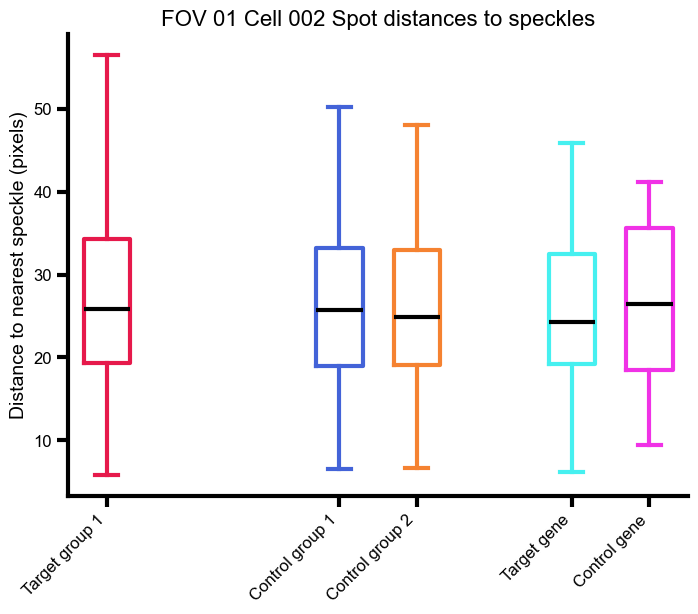

In [ ]:


fig,ax = plt.subplots(1,1,figsize=(8,6))
for i,group in enumerate(groups):
    speckle_positions = df[df.Hybe_annotation == 'SRRM1'].loc[:,['X','Y','Z']].values
    subset = df[df.Hybe_annotation == group]
    print(f'Group: {group}, Number of spots: {len(subset)}')
    subset_positions = subset.loc[:,['X','Y','Z']].values

    if len(speckle_positions) == 0 or len(subset_positions) == 0:
        continue
    distmap = np.zeros((len(speckle_positions),len(subset_positions)))
    for j,k in product(range(len(speckle_positions)), range(len(subset_positions))):
        distmap[j,k] = np.linalg.norm(speckle_positions[j]-subset_positions[k])
    
    ax.boxplot([distmap.flatten()], positions = [i], widths=0.6,
               labels=[group], showfliers=False,
               boxprops=dict(color=colors[i], linewidth=3),
               medianprops=dict(color='black', linewidth=3),
                whiskerprops=dict(color=colors[i], linewidth=3),
                capprops=dict(color=colors[i], linewidth=3),)
ax.set_ylabel('Distance to nearest speckle (pixels)', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(3)
ax.tick_params(axis='both', which='major', labelsize=12, length=8, width=3)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f'FOV {fov:02d} Cell {cid:03d} Spot distances to speckles', fontsize=16)
fig.savefig(os.path.join(image_save_path, f'FOV{fov:02d}_Cell{cid}_SpotDistancesToSpeckles.png'), dpi=300, bbox_inches='tight')

In [52]:
len([h for h in hybe_list if h.startswith('H') and int(h[1:]) < 180])

45